In [1]:
import pandas as pd
import matplotlib.pyplot as plt

fn = r'datasets/Revised_Final_Data/Station1_Revised_Final_Data.csv'
#Debugging iss
print(pd.read_csv(fn, nrows=0).columns.tolist())
#Load CSV, parse the timestamp column
df = pd.read_csv(fn, parse_dates=['Date'], index_col='Date')
df.head()


['Date', 'Ppt', 'SWC_5', 'SWC_10', 'SWC_20', 'SWC_50', 'T_5', 'T_10', 'T_20', 'T_50', 'Tair', 'RH', 'Windspeed', 'Winddirection', 'Srad', 'Latitude', 'Longitude']


,Ppt,SWC_5,SWC_10,SWC_20,SWC_50,T_5,T_10,T_20,T_50,Tair,RH,Windspeed,Winddirection,Srad,Latitude,Longitude
Date,,,,,,,,,,,,,,,,
2015-01-01 00:00:00,0.0,0.139,0.178,0.148,0.152,2.81,4.40,5.77,10.57,-1.090,81.5,1.052,52.27,0.63,30.3989,-98.6105
2015-01-01 01:00:00,0.0,0.139,0.178,0.148,0.152,2.86,4.38,5.71,10.51,-1.038,81.7,0.959,46.71,0.62,30.3989,-98.6105
2015-01-01 02:00:00,0.0,0.139,0.178,0.148,0.152,2.89,4.35,5.66,10.47,-0.981,82.0,1.062,52.04,0.60,30.3989,-98.6105
2015-01-01 03:00:00,0.0,0.139,0.178,0.148,0.152,2.90,4.33,5.62,10.41,-0.814,81.9,0.887,58.91,0.64,30.3989,-98.6105
2015-01-01 04:00:00,0.0,0.139,0.178,0.148,0.152,2.96,4.32,5.59,10.36,-0.805,90.0,0.828,16.55,0.20,30.3989,-98.6105


In [2]:
# Create rain flag, where precipitation is greater than 0
df['rain_flag'] = df['Ppt'] > 0

# Extract hour of day for future visualization
df['hour'] = df.index.hour

# Hours with rain proportion
print(df['rain_flag'].value_counts(normalize=True))

rain_flag
False    0.96035
True     0.03965
Name: proportion, dtype: float64


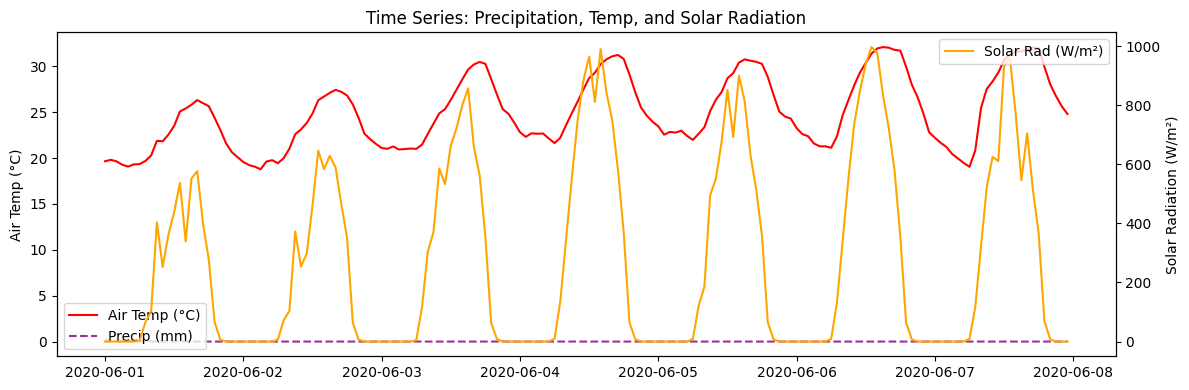

In [3]:
# Random 7 day period
week = df.loc['2020-06-01':'2020-06-07']

fig, ax1 = plt.subplots(figsize=(12,4))

# Air Temperature
ax1.plot(
    week.index,
    week['Tair'],
    label='Air Temp (°C)',
    color='red'
)
ax1.set_ylabel('Air Temp (°C)')
ax1.legend(loc='upper left')

# Solar Radiation
ax2 = ax1.twinx()
ax2.plot(
    week.index,
    week['Srad'],
    label='Solar Rad (W/m²)',
    color='orange'
)
ax2.set_ylabel('Solar Radiation (W/m²)')
ax2.legend(loc='upper right')

# Precipitation
ax1.plot(
    week.index,
    week['Ppt'],
    label='Precip (mm)',
    color='purple',
    linestyle='--',
    linewidth=1.5,
    alpha=0.8
)
ax1.legend(loc='lower left')

plt.title('Time Series: Precipitation, Temp, and Solar Radiation')
plt.tight_layout()
plt.show()


C:\Users\polis\AppData\Local\Temp\ipykernel_29104\165659043.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([temp_rain, temp_dry], labels=['Rain','Dry'])


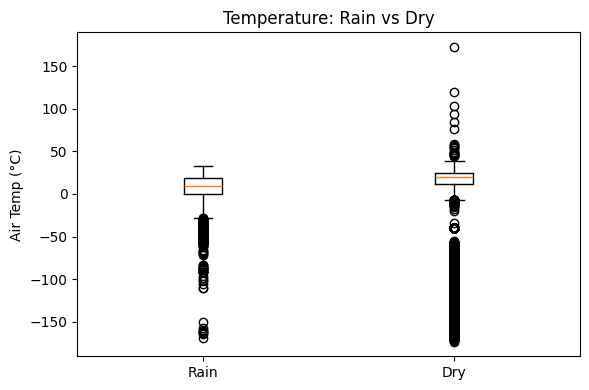

C:\Users\polis\AppData\Local\Temp\ipykernel_29104\165659043.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([sr_rain, sr_dry], labels=['Rain','Dry'])


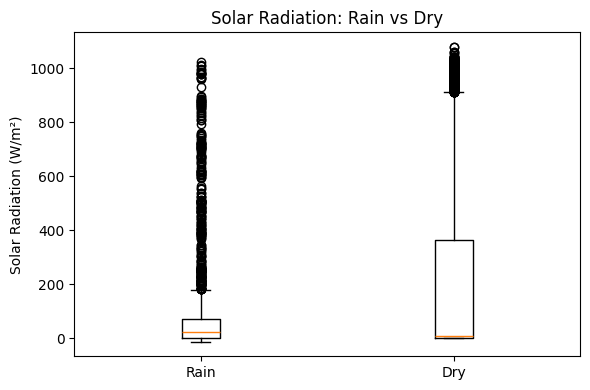

In [4]:
#Plots of how temp is affected by rain vs dry and how solar radiation is affected by rain vs dry

# Data Prep
temp_rain = df.loc[df['rain_flag'], 'Tair']
temp_dry  = df.loc[~df['rain_flag'], 'Tair']
sr_rain   = df.loc[df['rain_flag'], 'Srad']
sr_dry    = df.loc[~df['rain_flag'], 'Srad']

# Temperature boxplot
plt.figure(figsize=(6,4))
plt.boxplot([temp_rain, temp_dry], labels=['Rain','Dry'])
plt.ylabel('Air Temp (°C)')
plt.title('Temperature: Rain vs Dry')
plt.tight_layout()
plt.show()

# Solar Radiation boxplot
plt.figure(figsize=(6,4))
plt.boxplot([sr_rain, sr_dry], labels=['Rain','Dry'])
plt.ylabel('Solar Radiation (W/m²)')
plt.title('Solar Radiation: Rain vs Dry')
plt.tight_layout()
plt.show()


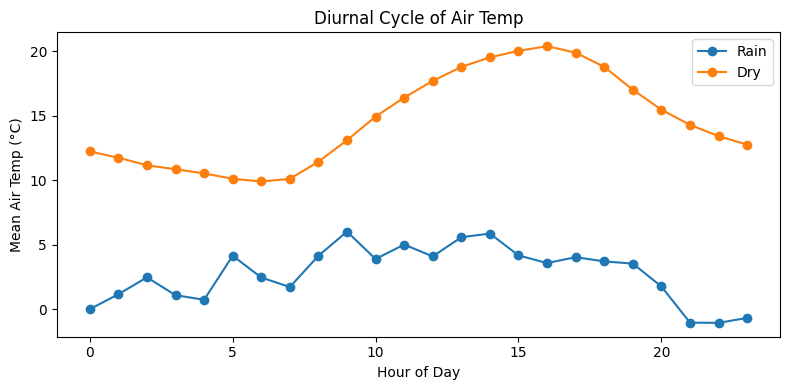

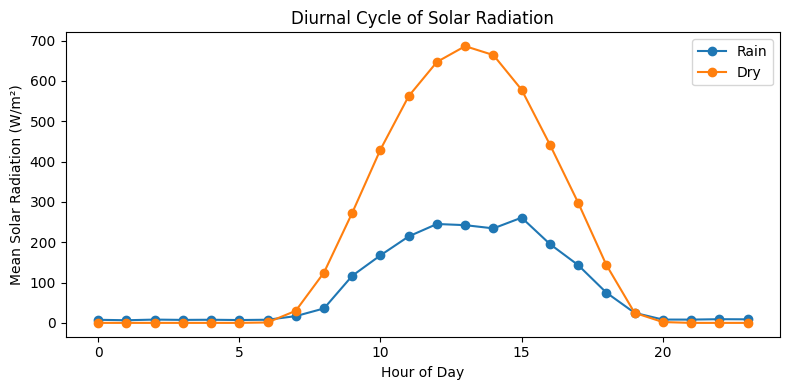

In [5]:
#Entire record, average temp per hour

# Group by hour and rain
grp = df.groupby(['rain_flag', 'hour'])[['Tair', 'Srad']].mean().reset_index()

# Air Temp diurnal
plt.figure(figsize=(8,4))
for flag, label in [(True, 'Rain'), (False, 'Dry')]:
    subset = grp[grp['rain_flag'] == flag]
    plt.plot(subset['hour'], subset['Tair'], marker='o', label=label)
plt.xlabel('Hour of Day')
plt.ylabel('Mean Air Temp (°C)')
plt.title('Diurnal Cycle of Air Temp')
plt.legend()
plt.tight_layout()
plt.show()

# Solar Radiation diurnal
plt.figure(figsize=(8,4))
for flag, label in [(True, 'Rain'), (False, 'Dry')]:
    subset = grp[grp['rain_flag'] == flag]
    plt.plot(subset['hour'], subset['Srad'], marker='o', label=label)
plt.xlabel('Hour of Day')
plt.ylabel('Mean Solar Radiation (W/m²)')
plt.title('Diurnal Cycle of Solar Radiation')
plt.legend()
plt.tight_layout()
plt.show()

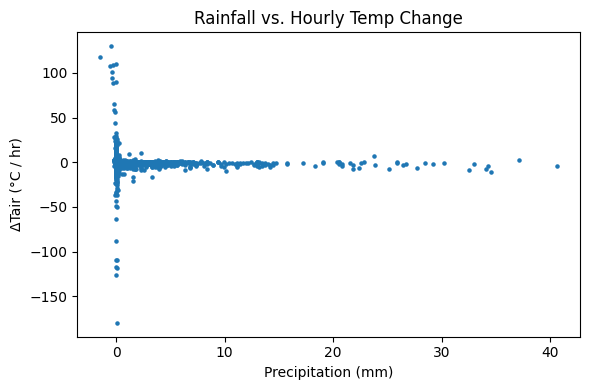

In [6]:
#check if larger hourly rain tends to coincide with bigger drops in air temp
df['Tair_diff'] = df['Tair'].diff()

plt.figure(figsize=(6,4))
plt.scatter(df['Ppt'], df['Tair_diff'], s=5)
plt.xlabel('Precipitation (mm)')
plt.ylabel('ΔTair (°C / hr)')
plt.title('Rainfall vs. Hourly Temp Change')
plt.tight_layout()
plt.show()
#Check for longer time windows check for highly negative data

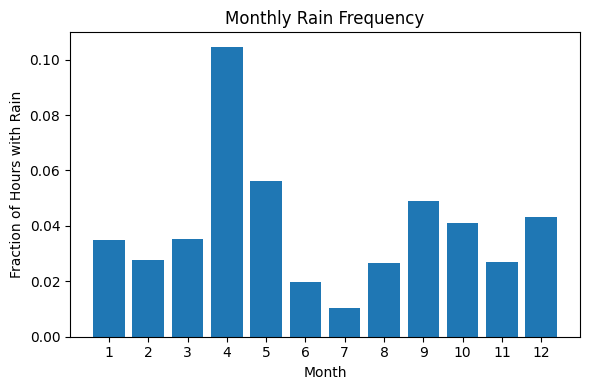

In [7]:
#Rain versus month, are there differences in rainfall by month?
df['month'] = df.index.month
monthly = df.groupby('month')['rain_flag'].mean()

plt.figure(figsize=(6,4))
plt.bar(monthly.index, monthly.values)
plt.xlabel('Month')
plt.ylabel('Fraction of Hours with Rain')
plt.title('Monthly Rain Frequency')
plt.xticks(range(1,13))
plt.tight_layout()
plt.show()
#Divide by station, year, etc.

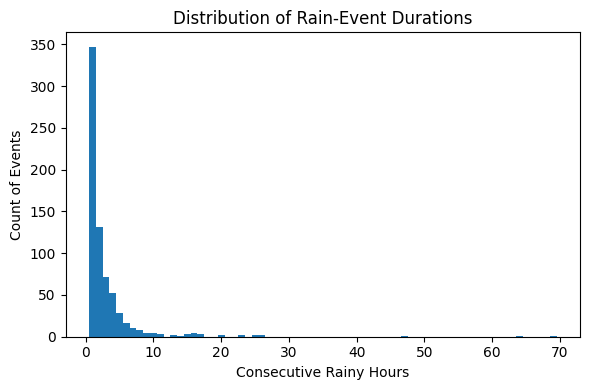

In [8]:
# find lengths of consecutive rainy hours
runs = df['rain_flag'].astype(int).groupby((df['rain_flag'] != df['rain_flag'].shift()).cumsum()).sum()
rain_runs = runs[df['rain_flag'].groupby((df['rain_flag'] != df['rain_flag'].shift()).cumsum()).first() == 1]

plt.figure(figsize=(6,4))
plt.hist(rain_runs, bins=range(1, rain_runs.max()+2), align='left')
plt.xlabel('Consecutive Rainy Hours')
plt.ylabel('Count of Events')
plt.title('Distribution of Rain‐Event Durations')
plt.tight_layout()
plt.show()

In [9]:
#Tair dry/rain and srad dry/rain for all stations
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#Find all Station CSVs
data_dir = 'datasets/Revised_Final_Data'
files = glob.glob(os.path.join(data_dir, 'Station*_Revised_Final_Data.csv'))

# Compute mean Tair/Srad for rain vs dry at each station
results = []
for fp in files:
    station = os.path.basename(fp).split('_')[0]
    df_i = pd.read_csv(fp, parse_dates=['Date'], index_col='Date')
    df_i['rain_flag'] = df_i['Ppt'] > 0
    mean_tair_rain = df_i.loc[df_i['rain_flag'], 'Tair'].mean()
    mean_tair_dry  = df_i.loc[~df_i['rain_flag'], 'Tair'].mean()
    mean_srad_rain = df_i.loc[df_i['rain_flag'], 'Srad'].mean()
    mean_srad_dry  = df_i.loc[~df_i['rain_flag'], 'Srad'].mean()
    results.append({
        'station': station,
        'Tair_dry': mean_tair_dry,
        'Tair_rain': mean_tair_rain,
        'Srad_dry': mean_srad_dry,
        'Srad_rain': mean_srad_rain
    })

res_df = pd.DataFrame(results).sort_values('station')
res_df

,station,Tair_dry,Tair_rain,Srad_dry,Srad_rain
0,Station1,14.607384,2.892276,204.368018,87.773395
1,Station2,19.242443,14.955445,204.063351,47.115883
2,Station3,19.275474,14.776410,206.537270,49.001936
3,Station4,19.741247,14.039517,207.026214,47.024587
4,Station5,19.651220,14.450851,212.724656,45.831859
5,Station6,19.312594,15.090613,209.387062,51.021997


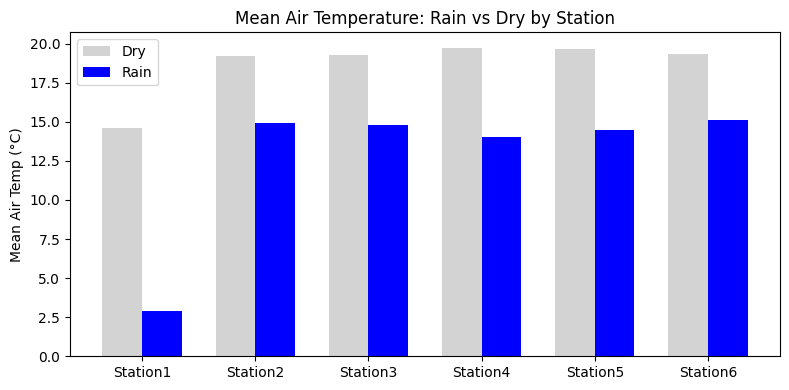

In [10]:
#Bar plot Temp wet vs dry by station
x = np.arange(len(res_df))
width = 0.35
fig, ax = plt.subplots(figsize=(8,4))
ax.bar(x - width/2, res_df['Tair_dry'], width, label='Dry', color='lightgrey')
ax.bar(x + width/2, res_df['Tair_rain'], width, label='Rain', color='blue')
ax.set_xticks(x)
ax.set_xticklabels(res_df['station'])
ax.set_ylabel('Mean Air Temp (°C)')
ax.set_title('Mean Air Temperature: Rain vs Dry by Station')
ax.legend()
plt.tight_layout()
plt.show()


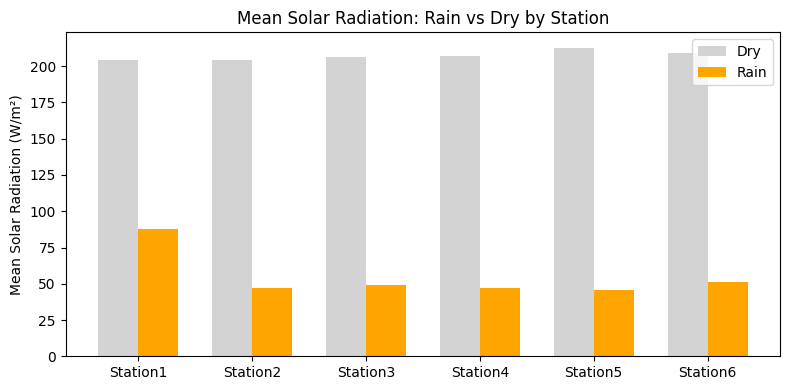

e


In [12]:
#Solar radiation by station
fig, ax = plt.subplots(figsize=(8,4))
ax.bar(x - width/2, res_df['Srad_dry'], width, label='Dry', color='lightgrey')
ax.bar(x + width/2, res_df['Srad_rain'], width, label='Rain', color='orange')
ax.set_xticks(x)
ax.set_xticklabels(res_df['station'])
ax.set_ylabel('Mean Solar Radiation (W/m²)')
ax.set_title('Mean Solar Radiation: Rain vs Dry by Station')
ax.legend()
plt.tight_layout()
plt.show()
print("e")